In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('flowers')

print("Files extracted successfully!")

Files extracted successfully!


In [ ]:
import os
print(os.listdir('flowers/flowers'))


['tulip', 'rose', 'daisy', 'sunflower', 'dandelion']


Epoch 1/10: Train Acc=0.2489, Val Acc=0.2716
Epoch 2/10: Train Acc=0.2512, Val Acc=0.2654
Epoch 3/10: Train Acc=0.2542, Val Acc=0.2577
Epoch 4/10: Train Acc=0.2499, Val Acc=0.2562
Epoch 5/10: Train Acc=0.2479, Val Acc=0.2546
Epoch 6/10: Train Acc=0.2483, Val Acc=0.2500
Epoch 7/10: Train Acc=0.2509, Val Acc=0.2469
Epoch 8/10: Train Acc=0.2496, Val Acc=0.2485
Epoch 9/10: Train Acc=0.2506, Val Acc=0.2485
Epoch 10/10: Train Acc=0.2473, Val Acc=0.2515
Test Accuracy: 0.24537037037037038
              precision    recall  f1-score   support

       tulip       0.24      0.03      0.06       148
        rose       0.00      0.00      0.00       118
       daisy       0.00      0.00      0.00       114
   sunflower       0.00      0.00      0.00       110
   dandelion       0.25      0.97      0.39       158

    accuracy                           0.25       648
   macro avg       0.10      0.20      0.09       648
weighted avg       0.11      0.25      0.11       648



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


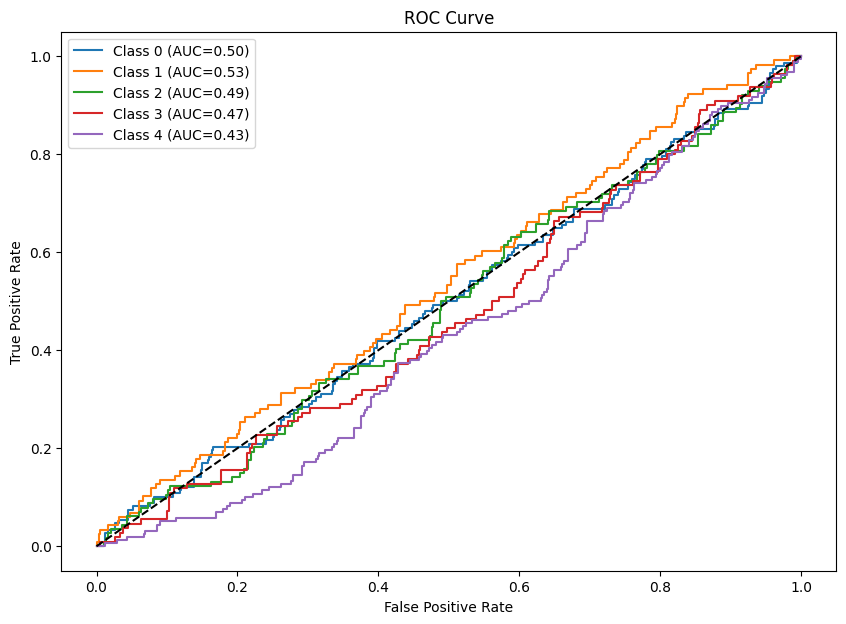

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

def load_data(data_dir, img_size=(64, 64)):
    classes = os.listdir(data_dir)
    X, y = [], []
    class_labels = {label: idx for idx, label in enumerate(classes)}

    for label in classes:
        label_dir = os.path.join(data_dir, label)
        for img_file in os.listdir(label_dir):
            img_path = os.path.join(label_dir, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(class_labels[label])

    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y)
    return X, y, class_labels

data_dir = "flowers/flowers"
X, y, class_labels = load_data(data_dir)

X = X.reshape(X.shape[0], -1)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

def initialize_weights(input_size, hidden_sizes, output_size):
    layers = [input_size] + hidden_sizes + [output_size]
    weights = []
    biases = []
    for i in range(len(layers) - 1):
        weights.append(np.random.randn(layers[i], layers[i+1]) * 0.01)
        biases.append(np.zeros((1, layers[i+1])))
    return weights, biases

def forward_pass(X, weights, biases):
    activations = []
    pre_activations = []
    a = X
    for i in range(len(weights)):
        z = np.dot(a, weights[i]) + biases[i]
        a = softmax(z) if i == len(weights) - 1 else relu(z)
        pre_activations.append(z)
        activations.append(a)
    return activations, pre_activations

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def backward_pass(X, y, weights, biases, activations, pre_activations):
    m = X.shape[0]
    y_onehot = np.eye(len(np.unique(y)))[y]
    grads_w = [None] * len(weights)
    grads_b = [None] * len(biases)

    dz = activations[-1] - y_onehot
    for i in reversed(range(len(weights))):
        grads_w[i] = np.dot((activations[i-1] if i > 0 else X).T, dz) / m
        grads_b[i] = np.sum(dz, axis=0, keepdims=True) / m
        if i > 0:
            da = np.dot(dz, weights[i].T)
            dz = da * (pre_activations[i-1] > 0)
    return grads_w, grads_b

def update_weights(weights, biases, grads_w, grads_b, learning_rate):
    for i in range(len(weights)):
        weights[i] -= learning_rate * grads_w[i]
        biases[i] -= learning_rate * grads_b[i]
    return weights, biases

def train(X_train, y_train, X_val, y_val, input_size, hidden_sizes, output_size, learning_rate, epochs):
    weights, biases = initialize_weights(input_size, hidden_sizes, output_size)
    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):
        activations, pre_activations = forward_pass(X_train, weights, biases)
        grads_w, grads_b = backward_pass(X_train, y_train, weights, biases, activations, pre_activations)
        weights, biases = update_weights(weights, biases, grads_w, grads_b, learning_rate)

        train_acc = accuracy_score(y_train, np.argmax(activations[-1], axis=1))
        val_activations, _ = forward_pass(X_val, weights, biases)
        val_acc = accuracy_score(y_val, np.argmax(val_activations[-1], axis=1))
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)
        print(f"Epoch {epoch+1}/{epochs}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    return weights, biases, train_acc_history, val_acc_history

input_size = X_train.shape[1]
hidden_sizes = [128, 64]
output_size = len(np.unique(y_train))
learning_rate = 0.01
epochs = 10
weights, biases, train_acc_history, val_acc_history = train(
    X_train, y_train, X_val, y_val, input_size, hidden_sizes, output_size, learning_rate, epochs
)

test_activations, _ = forward_pass(X_test, weights, biases)
y_pred = np.argmax(test_activations[-1], axis=1)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_labels.keys()))

def plot_roc_curve_and_auc(y_test, y_pred_proba, n_classes):
    fpr = {}
    tpr = {}
    roc_auc = {}
    y_onehot = np.eye(n_classes)[y_test]

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_onehot[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC={roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="best")
    plt.show()

plot_roc_curve_and_auc(y_test, test_activations[-1], output_size)
